# Automated annotation: CellAssign

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import scvi
import seaborn as sns
import torch
from scvi.external import CellAssign

/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/opt

In [2]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.2.0


In [3]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
#save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

In [4]:
l1 = sc.read('L1_annotation.h5ad')
l2 = sc.read('L2_annotation.h5ad')

celltype_markers = pd.read_csv('/home/sources/atlases/panel.tsv', sep='\t', skiprows=0)
celltype_markers = celltype_markers[~celltype_markers['Cell type'].isna()]
celltype_markers = celltype_markers[['TAIR', 'Cell type']].drop_duplicates()
# celltype_markers = celltype_markers[celltype_markers['Cell type'] != 'cambium']
# celltype_markers = celltype_markers[celltype_markers['Cell type'] != 'sieve element']

celltype_markers = celltype_markers.set_index('TAIR')
celltype_markers = celltype_markers.pivot(columns='Cell type', values='Cell type')
celltype_markers[~celltype_markers.isna()] = 1
celltype_markers[celltype_markers.isna()] = 0
celltype_markers['unknown'] = 0
celltype_markers = celltype_markers.astype(int)

l1.obs.index = l1.obs.index.astype("str")
l1.var.index = l1.var.index.astype("str")
l1.var_names_make_unique()
l1.obs_names_make_unique()

l2.obs.index = l2.obs.index.astype("str")
l2.var.index = l2.var.index.astype("str")
l2.var_names_make_unique()
l2.obs_names_make_unique()

l1

AnnData object with n_obs × n_vars = 3436 × 19325
    obs: 'n_count', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_cp', 'log1p_total_counts_cp', 'pct_counts_cp', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'cp_outlier', 'n_genes', 'scDblFinder_score', 'scDblFinder_class', 'size_factors', 'pp_score', 'S_score', 'G2M_score', 'phase', 'leiden_res0_5', 'leiden_res0_75', 'leiden_res1'
    var: 'gene_ids', 'mt', 'cp', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_deviant', 'binomial_deviance', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'dea_leiden_0_5', 'dendrogram_leiden_res0_5', 'hvg', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res0_75', 'leiden_res0_7

In [5]:
celltype_markers

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
TAIR,,,,,,,,,,,,,,,,,,,
AT1G06360,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
AT1G06490,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
AT1G07370,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AT1G07640,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
AT1G08810,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G61480,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
AT5G624701,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
AT5G62940,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [6]:
shared_genes_l1 = l1.var_names.intersection(celltype_markers.index)
shared_genes_l2 = l2.var_names.intersection(celltype_markers.index)

In [7]:
l1_bdata = l1[:, shared_genes_l1].copy()
l2_bdata = l2[:, shared_genes_l2].copy()

## L1 

In [8]:
scvi.external.CellAssign.setup_anndata(l1_bdata, layer='counts', size_factor_key="size_factors")

In [9]:
l1_model = CellAssign(l1_bdata, celltype_markers.loc[shared_genes_l1, :])
l1_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 1/400:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 400/400: 100%|██████████| 400/400 [05:39<00:00,  1.23it/s, v_num=1, train_loss_step=17.3, train_loss_epoch=19.1]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [05:39<00:00,  1.18it/s, v_num=1, train_loss_step=17.3, train_loss_epoch=19.1]


<Axes: xlabel='epoch'>

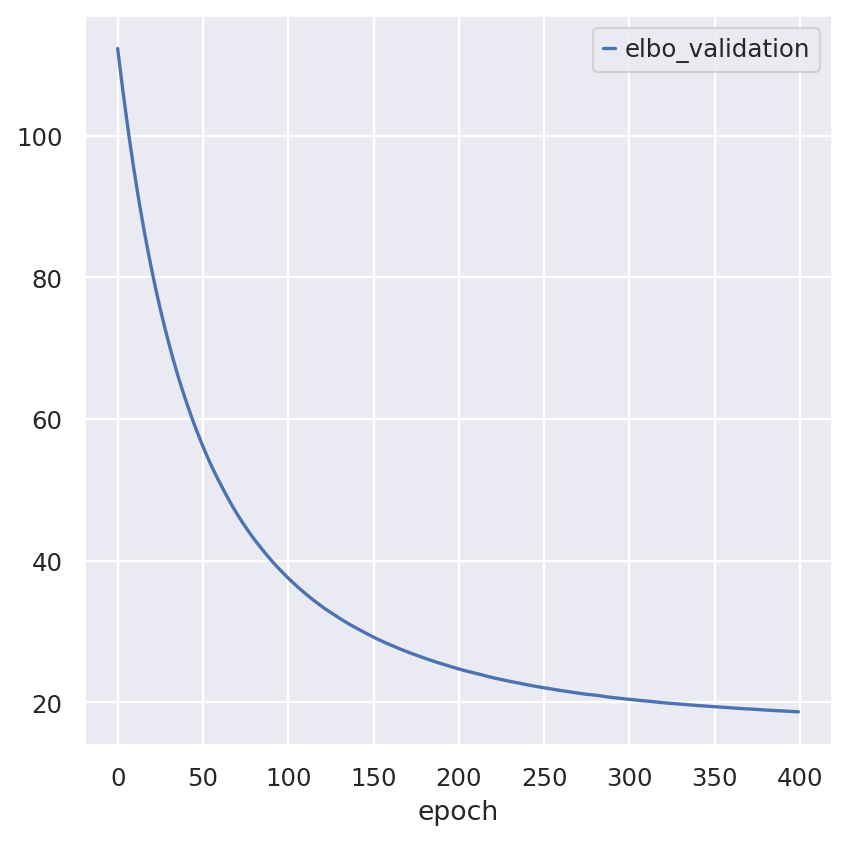

In [10]:
l1_model.history["elbo_validation"].plot()

In [11]:
predictions = l1_model.predict()
predictions.head()

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
0,1.885788e-06,0.000016,0.000749,3.040000e-06,0.000105,3.868839e-07,0.000029,0.000089,1.178861e-06,0.000036,0.000002,1.547776e-07,0.000231,0.000059,0.000663,0.010619,1.195010e-05,0.000026,0.987358
1,1.055263e-06,0.000012,0.000746,1.377657e-06,0.000085,3.122116e-07,0.000020,0.000077,7.013943e-07,0.000025,0.000001,4.607405e-07,0.003331,0.000045,0.000660,0.010571,1.494963e-03,0.000020,0.982907
2,3.478978e-05,0.000009,0.000749,1.845928e-05,0.000214,1.346524e-08,0.000079,0.000144,3.395490e-07,0.000089,0.000037,2.821676e-07,0.000372,0.000129,0.000663,0.010613,3.521327e-09,0.000060,0.986789
3,9.337076e-07,0.000093,0.000748,9.468639e-07,0.000077,1.040796e-04,0.000016,0.000072,1.993362e-06,0.000022,0.000001,8.374287e-07,0.000188,0.000040,0.000662,0.010605,1.239579e-03,0.000018,0.986109
4,1.418952e-06,0.000267,0.000747,2.215644e-06,0.000096,3.838786e-07,0.000025,0.000084,1.627060e-10,0.000031,0.000001,2.299566e-07,0.000217,0.000053,0.000661,0.010582,3.274203e-03,0.000023,0.983935


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


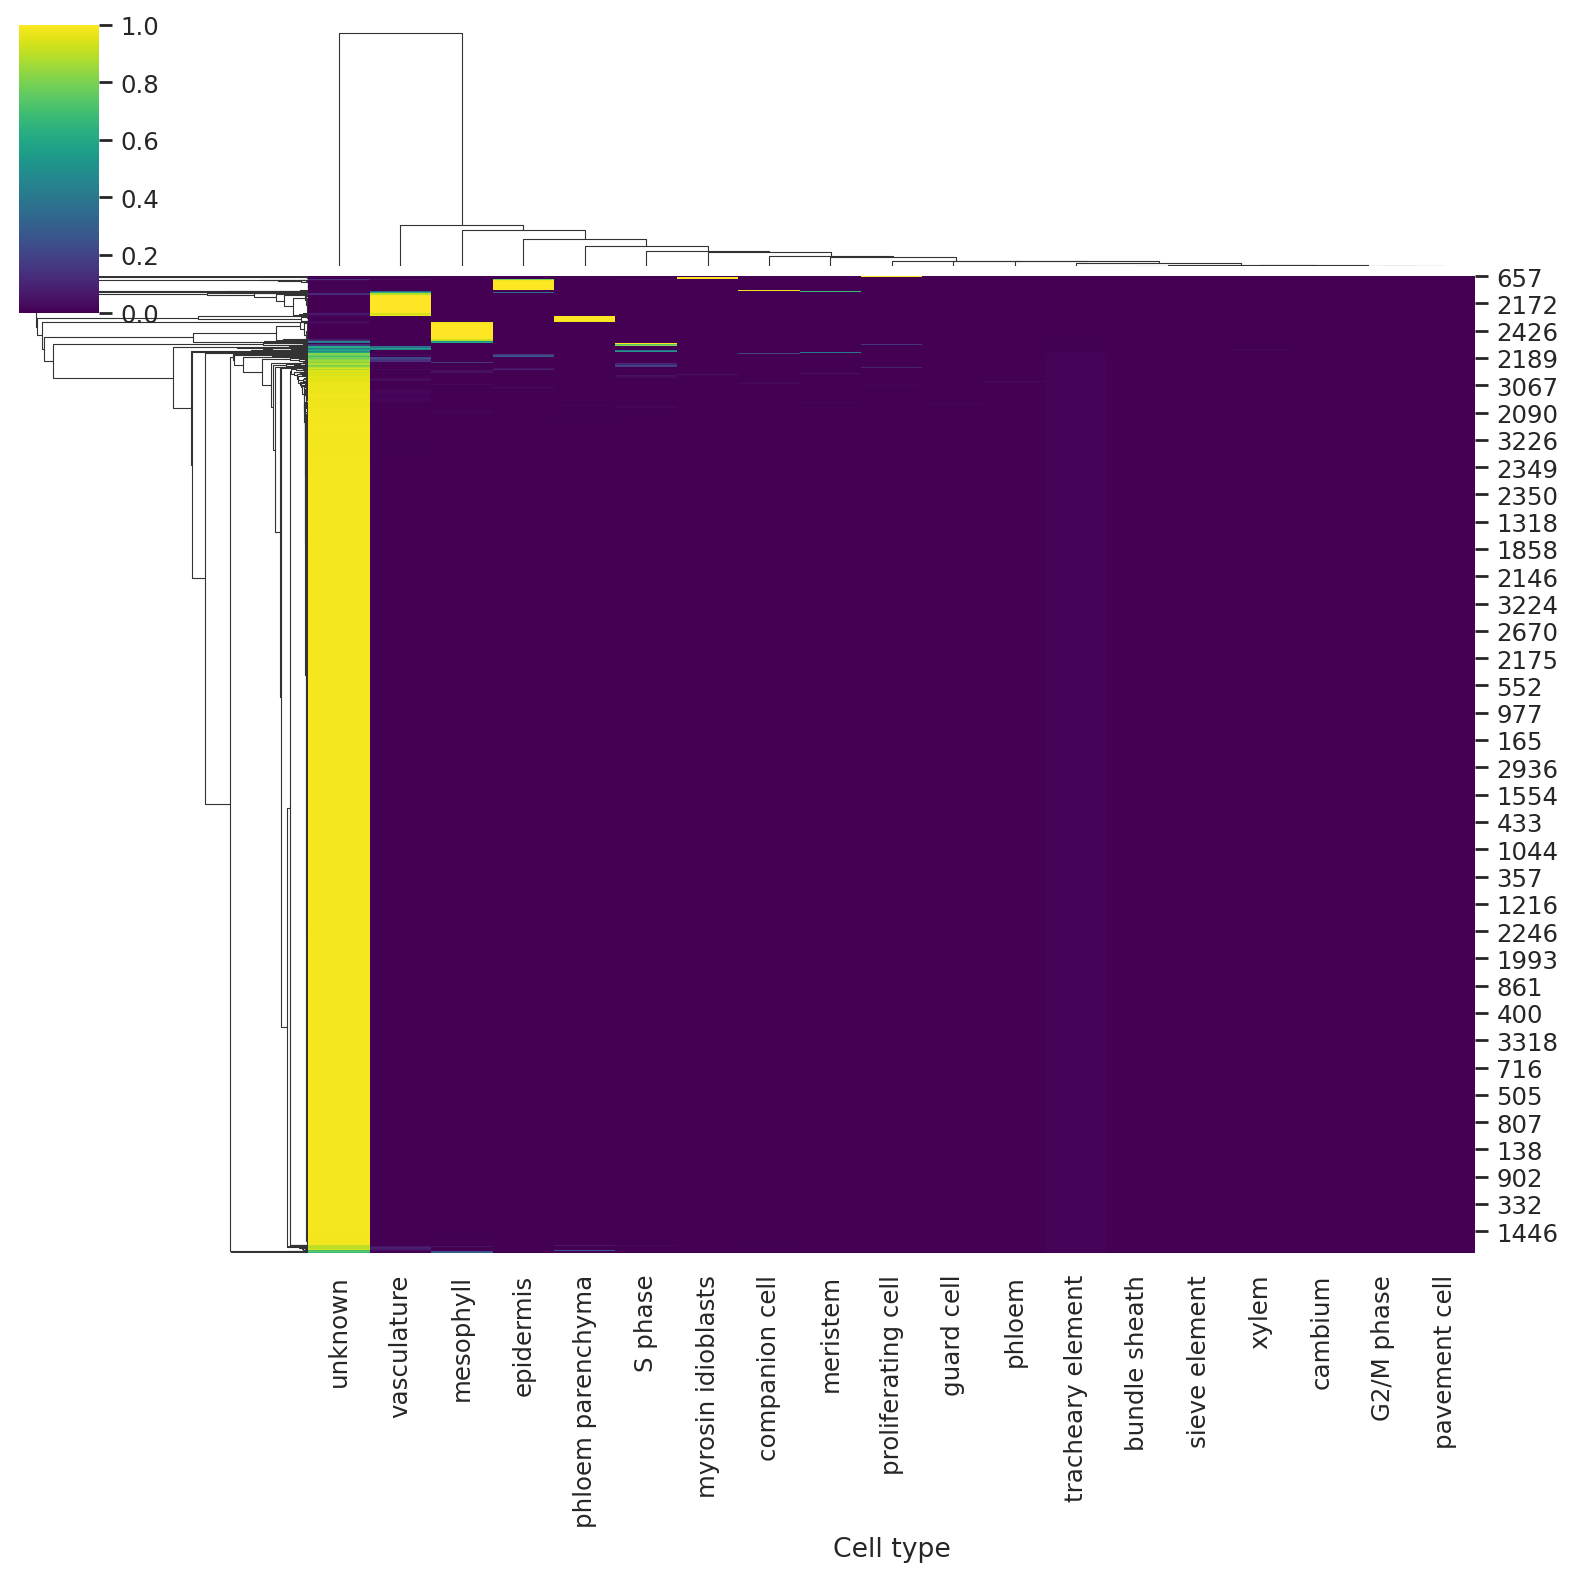

In [12]:
sns.clustermap(predictions, cmap="viridis")

In [13]:
l1_bdata.obs["cellassign_predictions"] = predictions.idxmax(axis=1).values

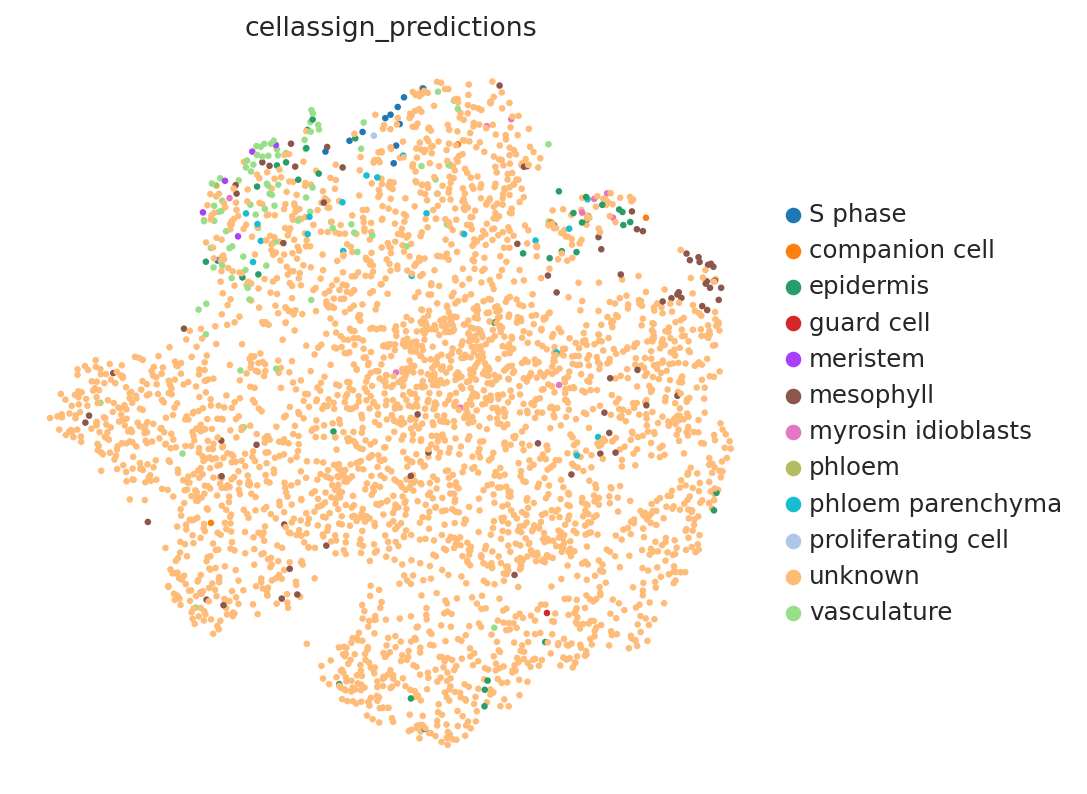

In [15]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l1_bdata,
    color=["cellassign_predictions"],
    frameon=False,
    ncols=1,
)

## L2

In [16]:
scvi.external.CellAssign.setup_anndata(l2_bdata, layer='counts', size_factor_key="size_factors")

In [17]:
l2_model = CellAssign(l2_bdata, celltype_markers.loc[shared_genes_l2, :])
l2_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 1/400:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 400/400: 100%|██████████| 400/400 [04:38<00:00,  1.63it/s, v_num=1, train_loss_step=22.9, train_loss_epoch=22.8]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [04:38<00:00,  1.44it/s, v_num=1, train_loss_step=22.9, train_loss_epoch=22.8]


<Axes: xlabel='epoch'>

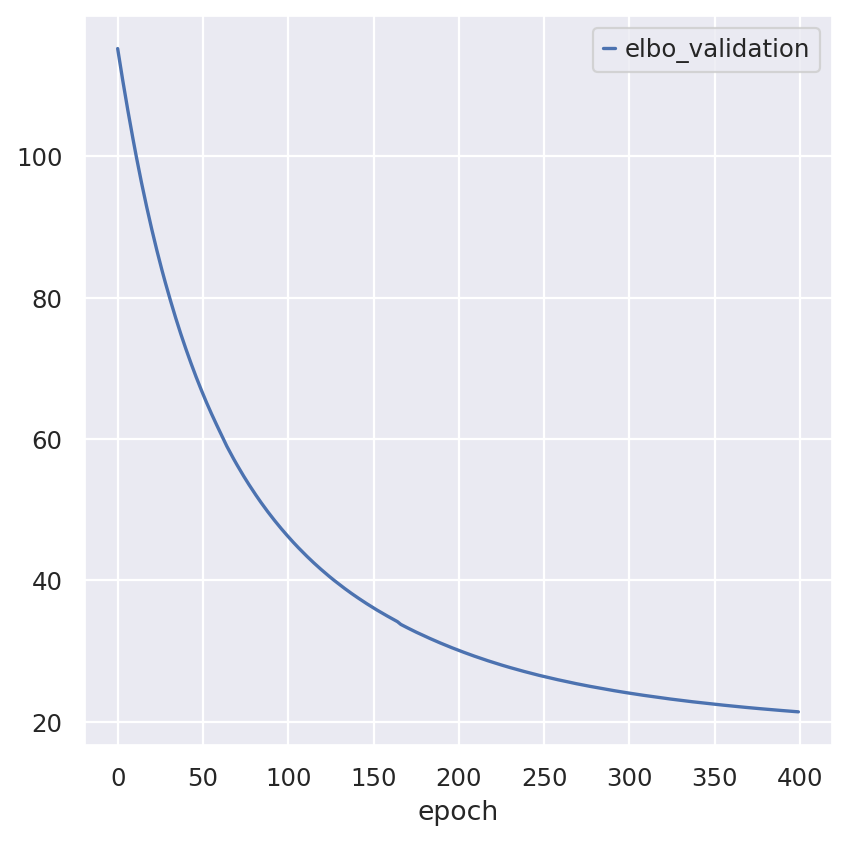

In [18]:
l2_model.history["elbo_validation"].plot()

In [19]:
predictions = l2_model.predict()
predictions.head()

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
0,0.000003,0.000080,2.196998e-06,0.000021,0.000044,2.462143e-07,0.000030,0.000047,6.599289e-08,0.000036,0.000024,0.000028,0.000095,0.000128,0.986217,0.000009,1.476220e-07,0.000103,0.013131
1,0.000020,0.000014,1.350080e-05,0.000048,0.000063,4.025661e-10,0.000044,0.000064,2.040388e-07,0.000052,0.000036,0.000041,0.000122,0.000175,0.986057,0.000025,1.024160e-08,0.000144,0.013083
2,0.000018,0.000016,1.223297e-05,0.000046,0.000374,6.449435e-10,0.000043,0.000063,1.942386e-07,0.000051,0.000035,0.000040,0.000120,0.000172,0.985763,0.000024,4.907621e-09,0.000141,0.013082
3,0.000002,0.000083,9.760529e-07,0.000009,0.000035,8.682927e-06,0.000024,0.000038,2.905316e-08,0.000028,0.000018,0.000021,0.000080,0.000103,0.986265,0.000004,3.190739e-05,0.000082,0.013166
4,0.000013,0.000022,8.909922e-06,0.000041,0.000058,4.436697e-05,0.000040,0.000059,6.534324e-07,0.000048,0.000033,0.000038,0.000115,0.000163,0.986069,0.000021,1.831816e-08,0.000133,0.013093


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


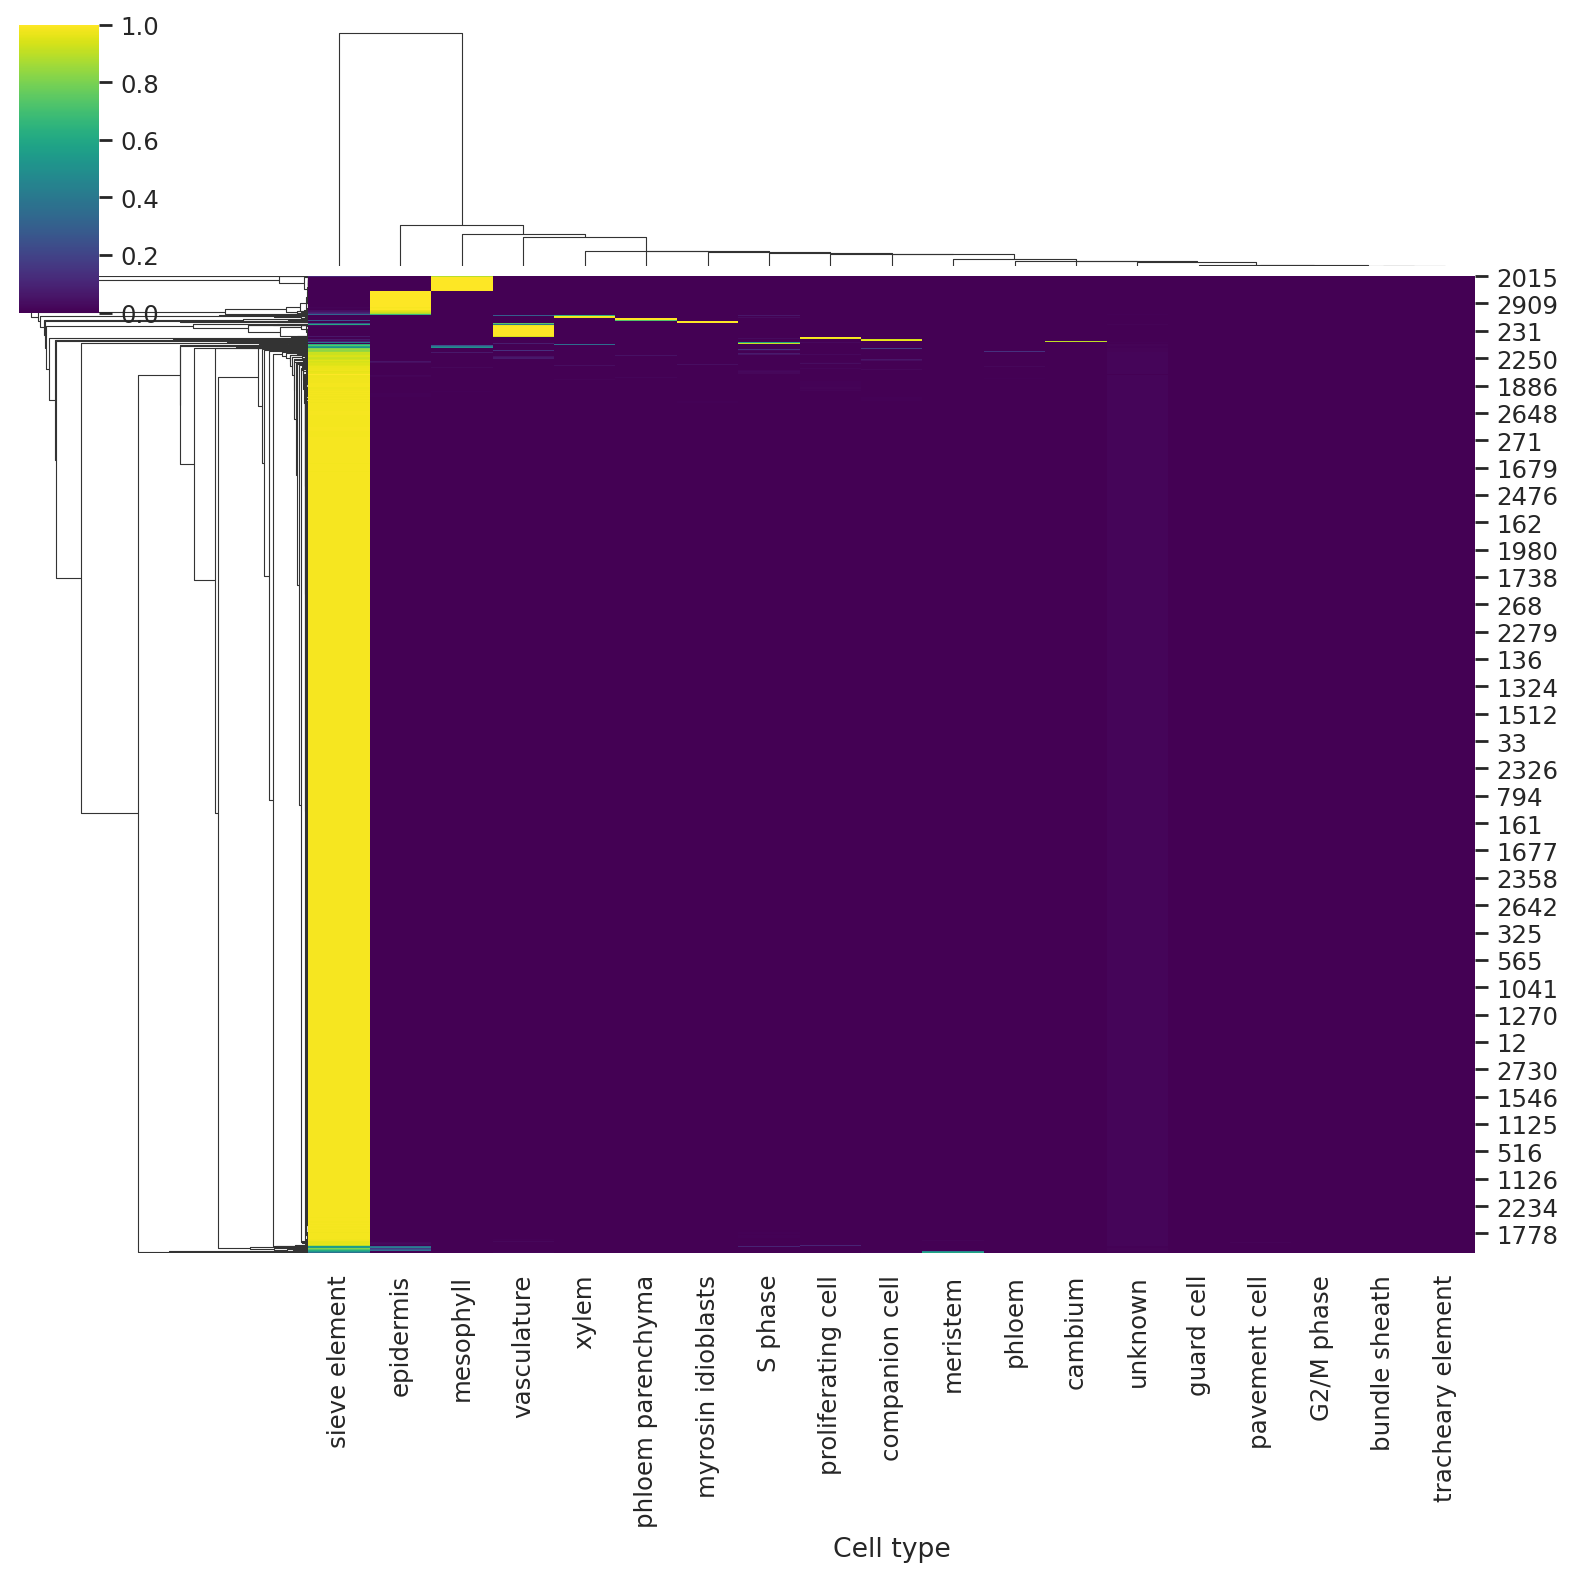

In [20]:
sns.clustermap(predictions, cmap="viridis")

In [21]:
l2_bdata.obs["cellassign_predictions"] = predictions.idxmax(axis=1).values

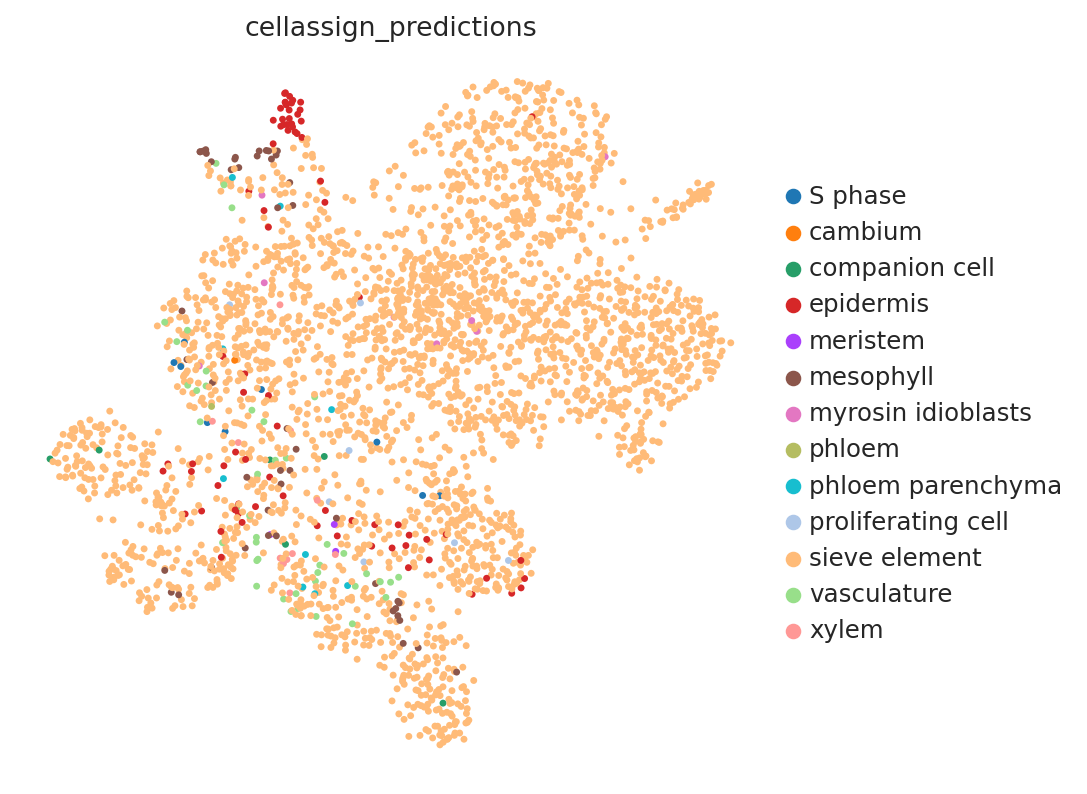

In [22]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l2_bdata,
    color=["cellassign_predictions"],
    frameon=False,
    ncols=1,
)

## L1 on SoupX layer

In [23]:
scvi.external.CellAssign.setup_anndata(l1_bdata, layer='soupX_counts', size_factor_key="size_factors")

In [24]:
l1_model = CellAssign(l1_bdata, celltype_markers.loc[shared_genes_l1, :])
l1_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 2/400:   0%|          | 1/400 [00:00<05:13,  1.27it/s, v_num=1, train_loss_step=100, train_loss_epoch=102]

Epoch 400/400: 100%|██████████| 400/400 [04:51<00:00,  1.45it/s, v_num=1, train_loss_step=15.1, train_loss_epoch=16.7]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [04:51<00:00,  1.37it/s, v_num=1, train_loss_step=15.1, train_loss_epoch=16.7]


<Axes: xlabel='epoch'>

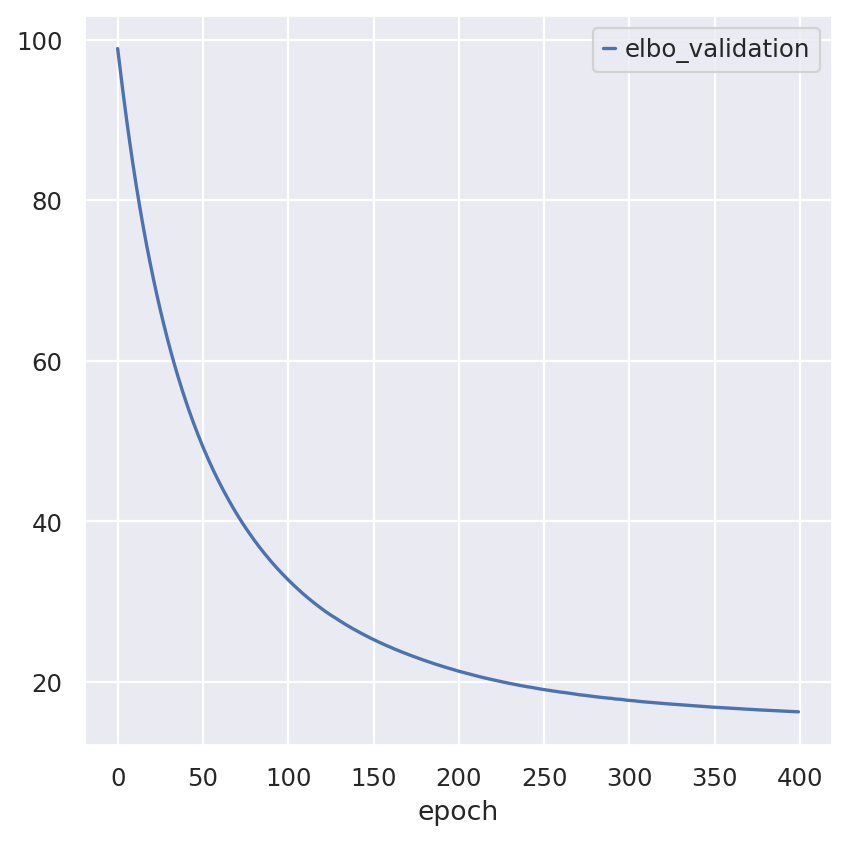

In [25]:
l1_model.history["elbo_validation"].plot()

In [26]:
predictions = l1_model.predict()
predictions.head()

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
0,1.301463e-06,0.000034,0.011132,1.164438e-06,0.000062,5.408056e-07,0.000123,1.197033e-05,0.000010,0.000074,9.712113e-07,0.000243,6.334125e-05,0.000063,0.000745,0.985496,0.000011,0.000040,0.001887
1,7.995785e-07,0.000018,0.011010,5.120875e-07,0.000053,3.500430e-07,0.000089,7.917590e-05,0.000006,0.000061,6.135318e-07,0.000202,1.086660e-02,0.000050,0.000737,0.974712,0.000215,0.000032,0.001867
2,1.942449e-05,0.002749,0.011096,1.581143e-05,0.000100,1.015647e-08,0.000284,1.894333e-07,0.000040,0.000132,1.535456e-05,0.000434,8.745657e-07,0.000116,0.000743,0.982246,0.000049,0.000079,0.001881
3,7.331356e-07,0.000111,0.011120,3.817152e-07,0.000050,4.053420e-05,0.000077,1.162158e-04,0.000017,0.000056,5.718856e-07,0.000189,6.387675e-04,0.000045,0.000744,0.984451,0.000427,0.000030,0.001885
4,1.024644e-06,0.000355,0.011108,8.181668e-07,0.000058,4.694749e-07,0.000109,3.012205e-05,0.000112,0.000068,7.718744e-07,0.000226,1.615210e-04,0.000057,0.000744,0.983372,0.001676,0.000037,0.001883


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


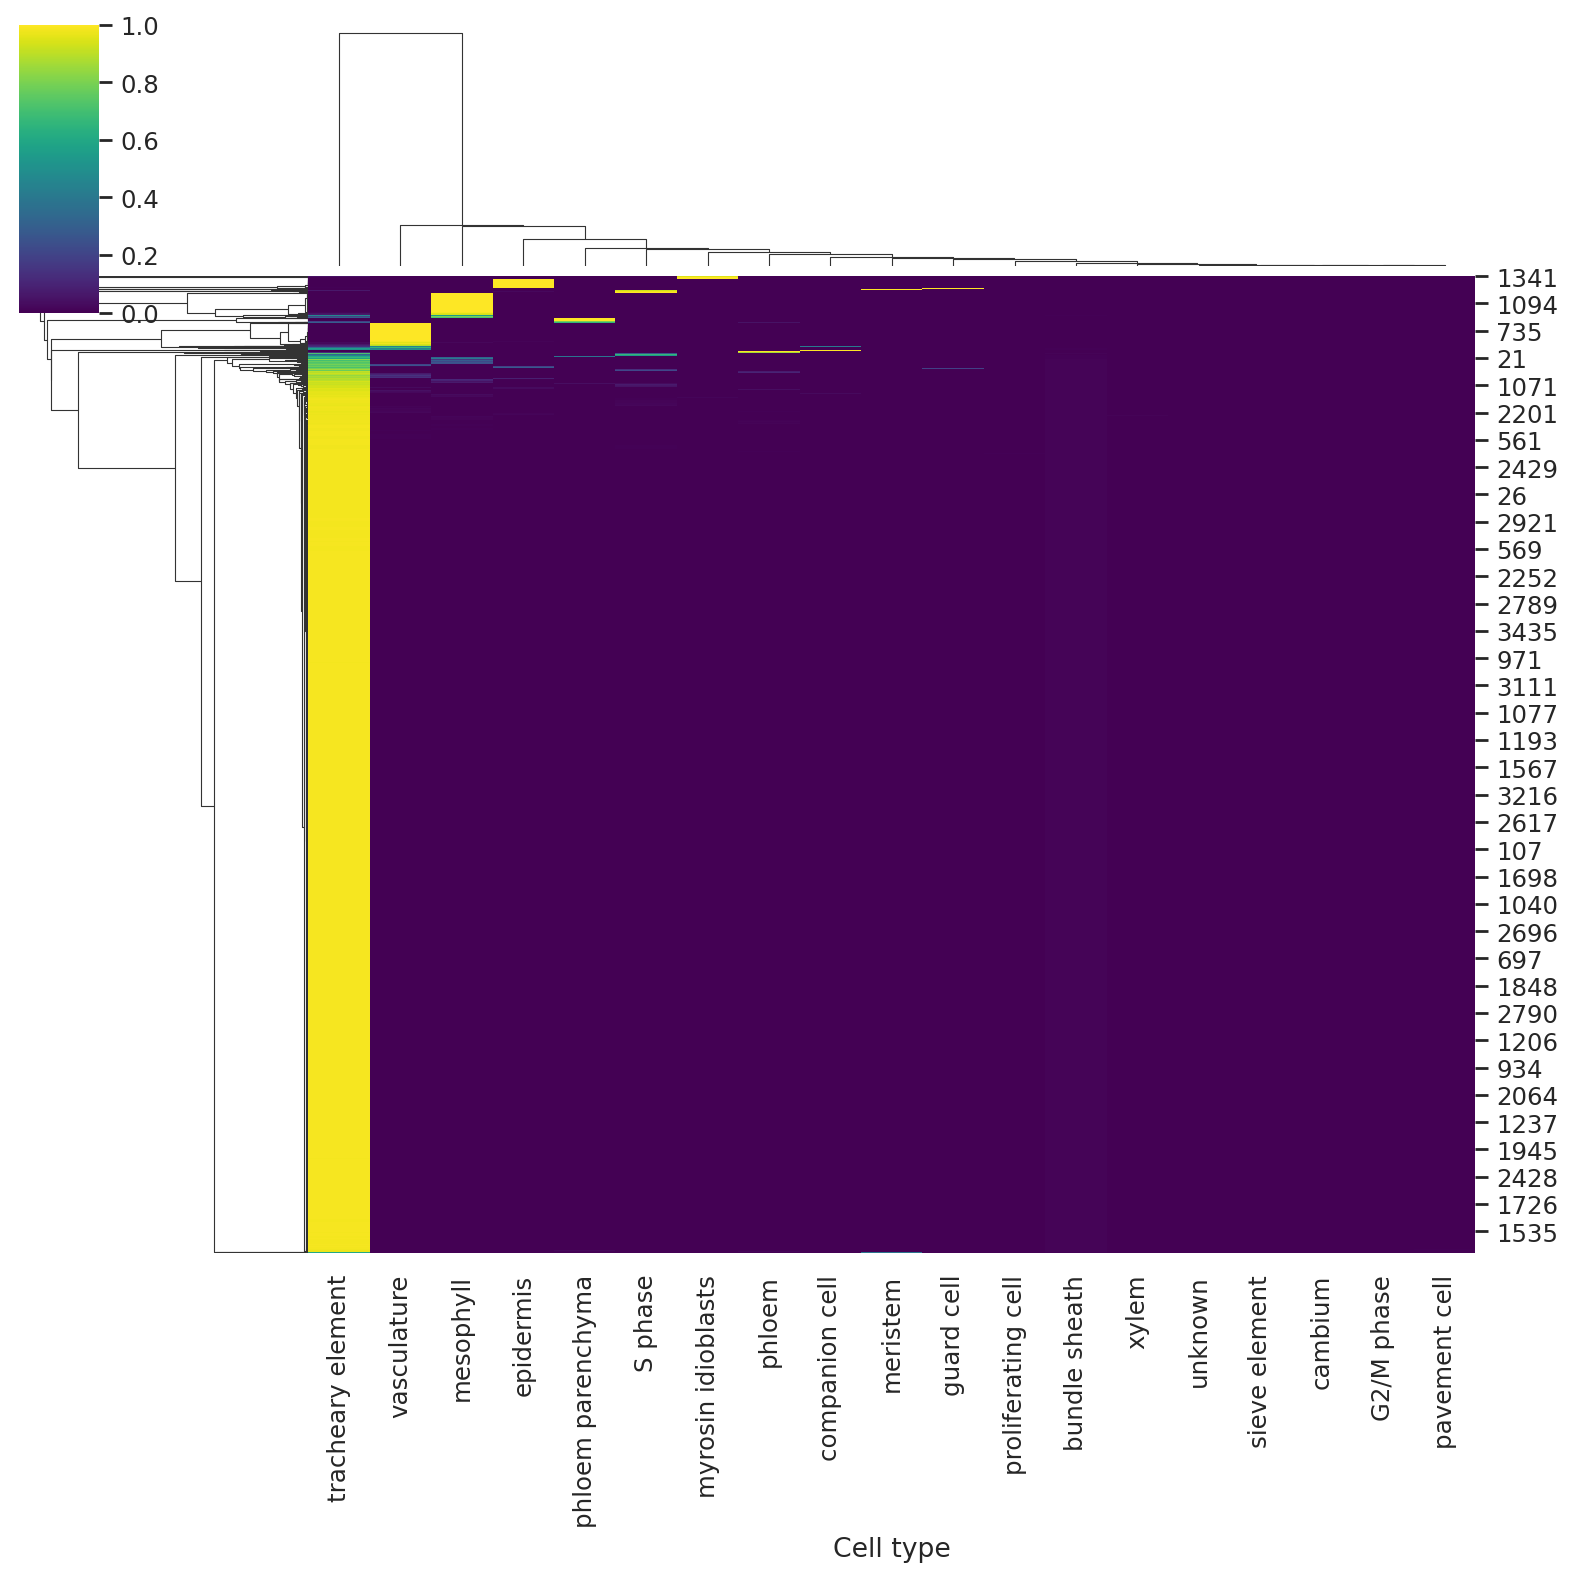

In [27]:
sns.clustermap(predictions, cmap="viridis")

In [28]:
l1_bdata.obs["cellassign_predictions_2"] = predictions.idxmax(axis=1).values

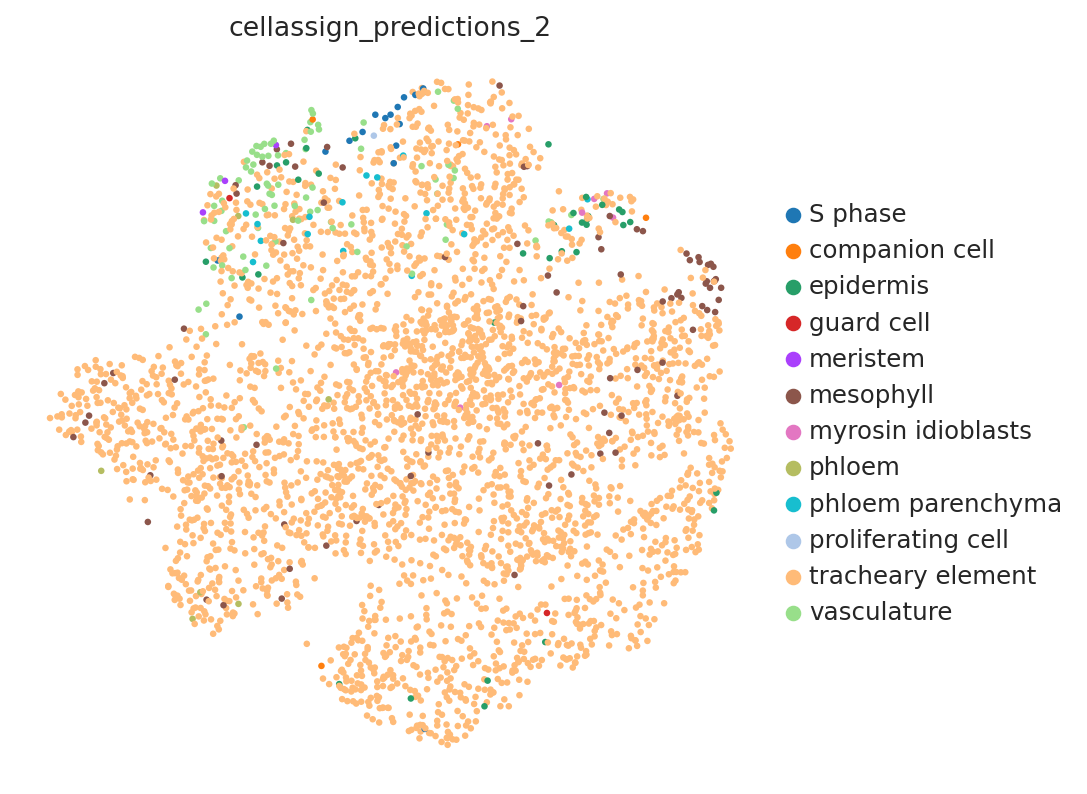

In [29]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l1_bdata,
    color=["cellassign_predictions_2"],
    frameon=False,
    ncols=1,
)

## L2 on SoupX layer

In [30]:
scvi.external.CellAssign.setup_anndata(l2_bdata, layer='soupX_counts', size_factor_key="size_factors")

In [31]:
l2_model = CellAssign(l2_bdata, celltype_markers.loc[shared_genes_l2, :])
l2_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 1/400:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 400/400: 100%|██████████| 400/400 [03:45<00:00,  1.64it/s, v_num=1, train_loss_step=20.2, train_loss_epoch=20.1]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [03:45<00:00,  1.77it/s, v_num=1, train_loss_step=20.2, train_loss_epoch=20.1]


<Axes: xlabel='epoch'>

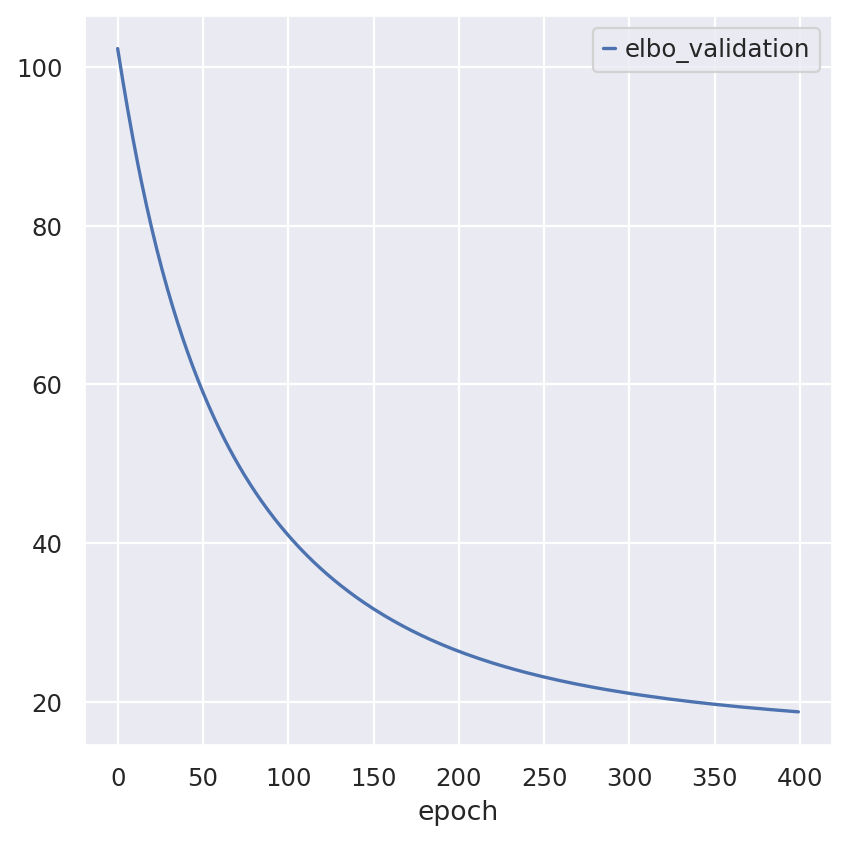

In [32]:
l2_model.history["elbo_validation"].plot()

In [33]:
predictions = l2_model.predict()
predictions.head()

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
0,0.000001,0.000046,0.005234,0.000131,0.000059,0.000001,0.000088,0.000087,2.938398e-07,0.000039,0.000043,0.000009,0.000189,0.000189,0.984937,0.000010,0.000020,0.000233,0.008684
1,0.000005,0.000080,0.005514,0.000169,0.000084,0.000004,0.000132,0.000127,8.408181e-07,0.000053,0.000062,0.000031,0.000242,0.000269,0.984304,0.000035,0.000011,0.000331,0.008546
2,0.000004,0.000078,0.005495,0.000167,0.000564,0.000003,0.000129,0.000124,8.049832e-07,0.000052,0.000061,0.000030,0.000239,0.000263,0.983880,0.000033,0.000002,0.000325,0.008549
3,0.000001,0.000026,0.005046,0.000109,0.000047,0.000010,0.000067,0.000067,1.363927e-07,0.000031,0.000033,0.000003,0.000160,0.000147,0.983853,0.000003,0.001439,0.000182,0.008777
4,0.000003,0.000069,0.005232,0.000153,0.000074,0.039689,0.000116,0.000112,4.228404e-06,0.000047,0.000055,0.000024,0.000220,0.000238,0.945404,0.000027,0.000004,0.000294,0.008236


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


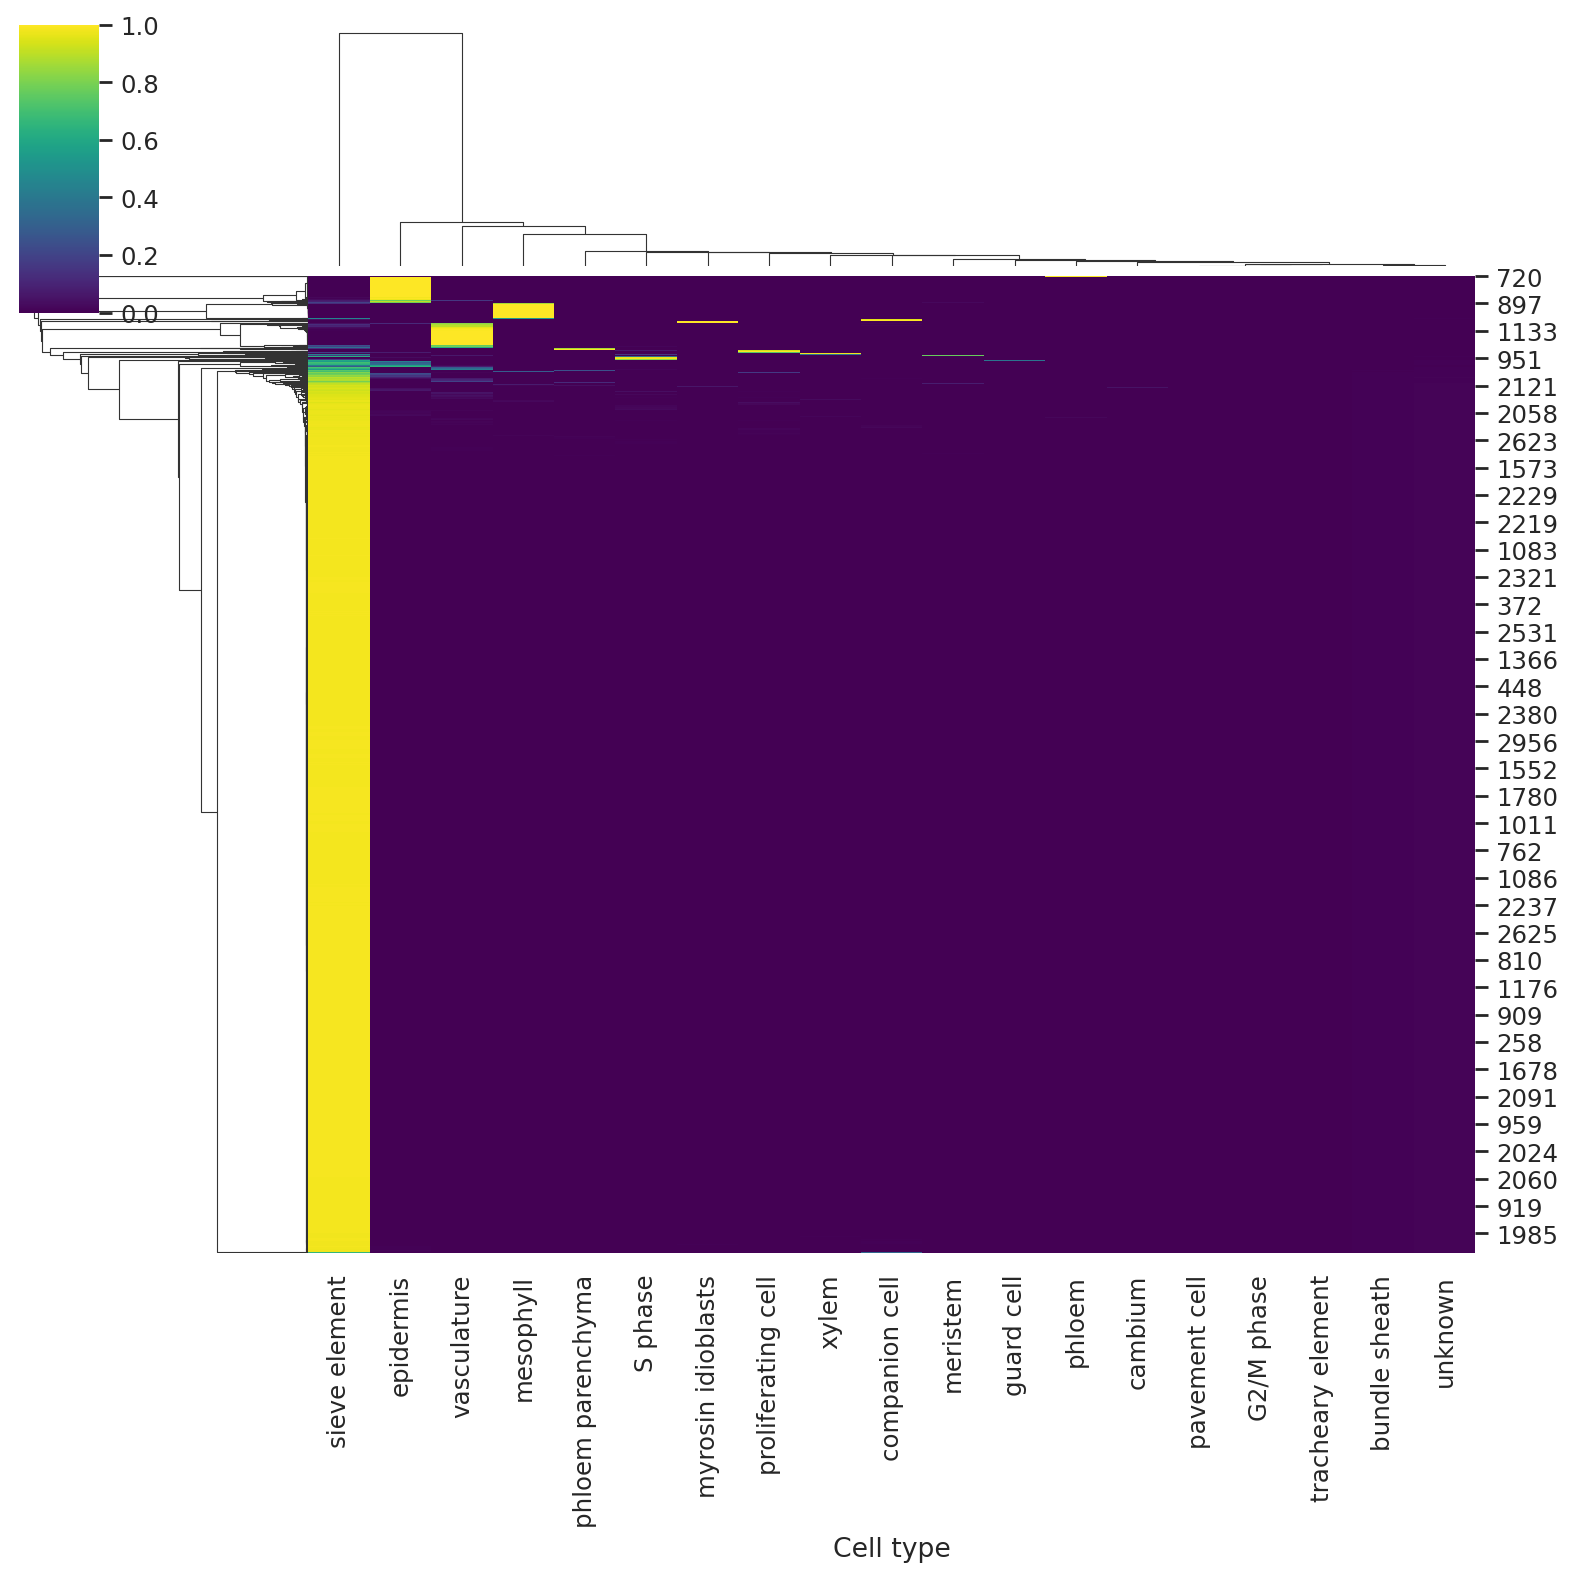

In [34]:
sns.clustermap(predictions, cmap="viridis")

In [35]:
l2_bdata.obs["cellassign_predictions_2"] = predictions.idxmax(axis=1).values

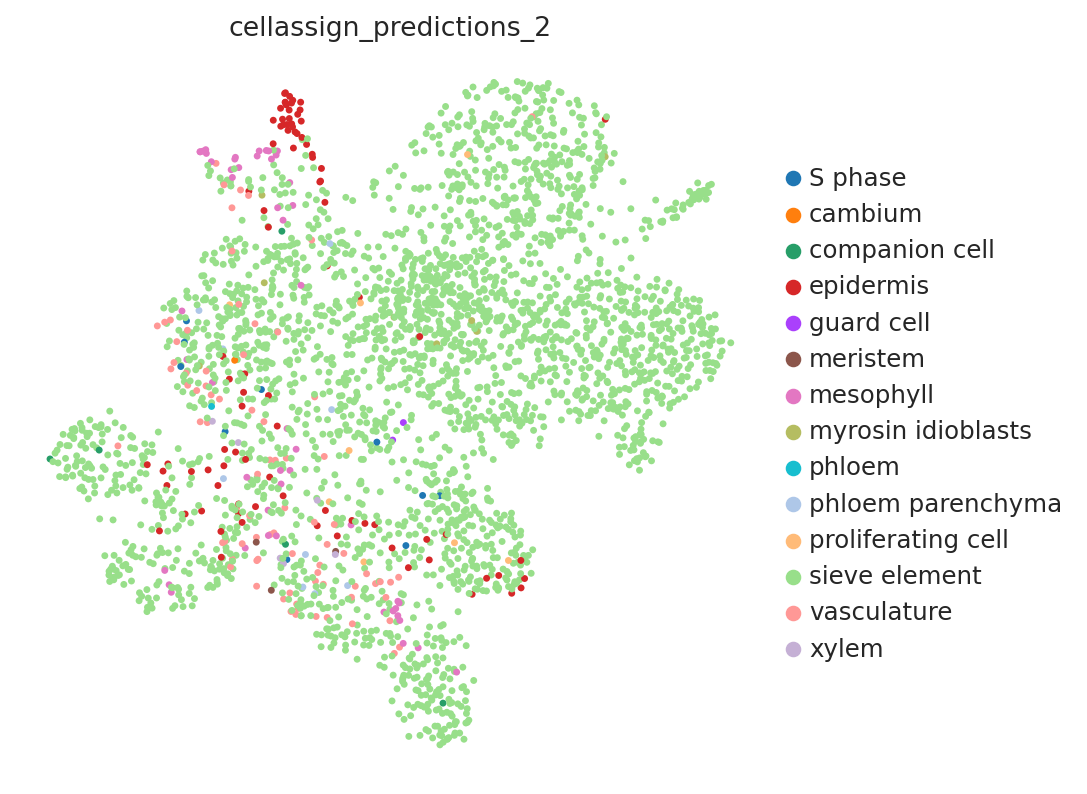

In [36]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l2_bdata,
    color=["cellassign_predictions_2"],
    frameon=False,
    ncols=1,
)

In [37]:
l1.write("L1_annotation.h5ad")
l2.write("L2_annotation.h5ad")